# RaBitQ Native IVF: Relative Error and ADC Timing

This notebook uses the completed native `RaBitQ-Library` IVF outputs under `/mnthdd/cpanourg/2-hdvc/results/rabitq`.

- Input CSVs: `*_RaBitQ-Library_adc_vs_exact_eval.csv`
- Output figures: `figures/rabitq_native_ivf_qinco_style`

Plot style intentionally mirrors `qinco_res_relerr.ipynb`: same rcparams, same line styling, same heatmap layout, and the Pareto figure only highlights and annotates the lower-left frontier points in red.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

PROJECT_ROOT = Path('/home/cpanourg/projects/2-hdvc')
FIGURE_DIR = PROJECT_ROOT / 'scripts' / 'figure_generators'
if str(FIGURE_DIR) not in sys.path:
    sys.path.insert(0, str(FIGURE_DIR))

from relerr_quick_plot_style import (
    COLOR_PALETTE,
    MARKER_PALETTE,
    apply_relerr_cpp_rcparams,
    plot_curve_relerr_style,
)

RESULT_ROOT = Path('/mnthdd/cpanourg/2-hdvc/results/rabitq')
OUT_DIR = RESULT_ROOT / 'figures' / 'rabitq_native_ivf_qinco_style'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['bigann', 'deep', 'gist', 'msmarco', 'openai']
SAVE_FORMATS = ('png', 'pdf')

apply_relerr_cpp_rcparams()
print('Result root:', RESULT_ROOT)
print('Output dir:', OUT_DIR)

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)


Result root: /mnthdd/cpanourg/2-hdvc/results/rabitq
Output dir: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style


In [2]:
def _numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def _dataset_short_name(name: str) -> str:
    mapping = {
        'bigann10k': 'bigann',
        'deep10k': 'deep',
        'gist10k': 'gist',
        'msmarco10k': 'msmarco',
        'openai10k': 'openai',
    }
    return mapping.get(str(name), str(name))


def load_rabitq_native_ivf(result_root: Path = RESULT_ROOT) -> pd.DataFrame:
    paths = sorted(result_root.glob('*_RaBitQ-Library_adc_vs_exact_eval.csv'))
    if not paths:
        raise FileNotFoundError(f'No RaBitQ-Library CSVs found in {result_root}')
    frames = []
    for path in paths:
        df = pd.read_csv(path)
        if 'dataset' not in df.columns:
            df['dataset'] = path.name.split('_')[0]
        frames.append(df)
    raw = pd.concat(frames, ignore_index=True)
    raw['dataset'] = raw['dataset'].map(_dataset_short_name)
    raw = _numeric(
        raw,
        [
            'nbits', 'bits_per_vector', 'train_size', 'train_time_s', 'encoding_time_s',
            'distance_table_time_s', 'cdist_time_s', 'adc_time_s', 'adc_time_s_std',
            'per_query_us_mean', 'per_pair_ns_mean', 'rel_error_mean', 'rel_error_std',
            'nq', 'nb', 'nb_sample', 'nq_sample', 'dim', 'n_subquantizers',
            'seed', 'n_centroids', 'nprobe',
        ],
    )
    raw['K'] = raw['n_centroids'].astype('Int64')
    raw['bits'] = raw['nbits'].astype('Int64')
    raw['adc_time_per_pair_ns'] = raw['per_pair_ns_mean']
    raw['adc_time_per_pair_s'] = raw['per_pair_ns_mean'] * 1e-9
    return raw


def build_plot_df() -> pd.DataFrame:
    raw = load_rabitq_native_ivf()
    key_cols = ['dataset', 'K', 'bits', 'nbits', 'bits_per_vector']
    plot_df = (
        raw.groupby(key_cols, as_index=False)
        .agg(
            adc_time_per_pair_ns=('adc_time_per_pair_ns', 'mean'),
            adc_time_per_pair_s=('adc_time_per_pair_s', 'mean'),
            adc_time_s=('adc_time_s', 'mean'),
            per_query_us_mean=('per_query_us_mean', 'mean'),
            rel_error_mean=('rel_error_mean', 'mean'),
            rel_error_std=('rel_error_std', 'mean'),
            train_size=('train_size', 'mean'),
            nq=('nq', 'mean'),
            nb=('nb', 'mean'),
            nb_sample=('nb_sample', 'mean'),
            timing_rows=('adc_time_per_pair_ns', 'size'),
            method=('method', 'first'),
        )
        .sort_values(['dataset', 'K', 'bits'])
        .reset_index(drop=True)
    )
    return plot_df


plot_df = build_plot_df()
print('Rows:', len(plot_df))
print(plot_df.groupby('dataset').size())
display(plot_df.head())


Rows: 270
dataset
bigann     54
deep       54
gist       54
msmarco    54
openai     54
dtype: int64


,dataset,K,bits,nbits,bits_per_vector,adc_time_per_pair_ns,adc_time_per_pair_s,adc_time_s,per_query_us_mean,rel_error_mean,rel_error_std,train_size,nq,nb,nb_sample,timing_rows,method
0,bigann,1,1,1,128,671.927,6.719270e-07,0.067193,67.1927,0.117065,0.081608,10000.0,1000.0,10000.0,100.0,1,RaBitQ-Library
1,bigann,1,2,2,256,995.844,9.958440e-07,0.099584,99.5844,0.053219,0.042048,10000.0,1000.0,10000.0,100.0,1,RaBitQ-Library
2,bigann,1,3,3,384,1007.390,1.007390e-06,0.100739,100.7390,0.026099,0.021207,10000.0,1000.0,10000.0,100.0,1,RaBitQ-Library
3,bigann,1,4,4,512,1095.160,1.095160e-06,0.109516,109.5160,0.015658,0.012729,10000.0,1000.0,10000.0,100.0,1,RaBitQ-Library
4,bigann,1,5,5,640,1053.790,1.053790e-06,0.105379,105.3790,0.006778,0.005539,10000.0,1000.0,10000.0,100.0,1,RaBitQ-Library


In [3]:
def style_axes(ax, x_label: str, y_label: str, *, grid_axis: str = 'y', x_log: bool = False, y_log: bool = False):
    ax.set_xlabel(x_label, fontsize=40)
    ax.set_ylabel(y_label, fontsize=40)
    ax.tick_params(labelsize=40)
    if x_log:
        ax.set_xscale('log')
    if y_log:
        ax.set_yscale('log')
    ax.grid(False)
    ax.grid(alpha=0.8, axis=grid_axis, linestyle='--')
    for spine in ax.spines.values():
        spine.set_visible(False)
    if not x_log:
        fmt_x = ScalarFormatter(useMathText=False)
        fmt_x.set_scientific(False)
        ax.xaxis.set_major_formatter(fmt_x)
    if not y_log:
        fmt_y = ScalarFormatter(useMathText=False)
        fmt_y.set_scientific(False)
        ax.yaxis.set_major_formatter(fmt_y)


def set_explicit_xticks(ax, *, x_col: str, values):
    vals = sorted({int(v) for v in values if pd.notna(v)})
    if not vals:
        return
    if x_col == 'bits':
        ax.set_xticks(vals)
        ax.set_xticklabels([str(v) for v in vals])
    elif x_col == 'K':
        preferred = [1, 16, 256, 1024]
        ticks = [v for v in preferred if v in vals]
        if len(ticks) < 4:
            idx = np.linspace(0, len(vals) - 1, 4).round().astype(int)
            ticks = [vals[i] for i in idx]
            ticks = list(dict.fromkeys(ticks))
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(v) for v in ticks])


def save_figure(fig, stem: str):
    saved = []
    for fmt in SAVE_FORMATS:
        path = OUT_DIR / f'{stem}.{fmt}'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        saved.append(path)
    print('Saved:', ', '.join(str(p) for p in saved))


def plot_lines_by_group(
    df: pd.DataFrame,
    *,
    dataset: str,
    x_col: str,
    y_col: str,
    group_col: str,
    x_label: str,
    y_label: str,
    stem: str,
    title: str | None = None,
    x_log: bool = False,
    y_log: bool = False,
):
    sub = df[df['dataset'] == dataset].dropna(subset=[x_col, y_col, group_col]).copy()
    if sub.empty:
        return None
    apply_relerr_cpp_rcparams()
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (group_value, group_df) in enumerate(sorted(sub.groupby(group_col), key=lambda kv: float(kv[0]))):
        group_df = group_df.sort_values(x_col)
        label = f'{group_col}={int(group_value)}'
        plot_curve_relerr_style(
            ax,
            group_df,
            x_col=x_col,
            y_col=y_col,
            label=label,
            color=COLOR_PALETTE[i % len(COLOR_PALETTE)],
            marker=MARKER_PALETTE[i % len(MARKER_PALETTE)],
        )
    style_axes(ax, x_label, y_label, x_log=x_log, y_log=y_log)
    set_explicit_xticks(ax, x_col=x_col, values=sub[x_col].unique())
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=18)
    save_figure(fig, f'{dataset}_{stem}')
    plt.show()
    plt.close(fig)
    return fig


def plot_heatmap(
    df: pd.DataFrame,
    *,
    dataset: str,
    value_col: str,
    value_label: str,
    stem: str,
    cmap: str = 'viridis',
):
    sub = df[df['dataset'] == dataset].dropna(subset=['K', 'bits', value_col]).copy()
    if sub.empty:
        return None
    pivot = sub.pivot_table(index='bits', columns='K', values=value_col, aggfunc='mean').sort_index().sort_index(axis=1)
    apply_relerr_cpp_rcparams()
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap=cmap)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(int(v)) for v in pivot.columns], rotation=0)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(int(v)) for v in pivot.index])
    style_axes(ax, 'K', 'Bits per dimension')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_label, fontsize=26)
    cbar.ax.tick_params(labelsize=20)
    save_figure(fig, f'{dataset}_{stem}')
    plt.show()
    plt.close(fig)
    return fig


## Relative Error Plots

The relative-error values below come directly from the native `RaBitQ-Library` evaluation CSVs.

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_relerr_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_relerr_vs_bits_by_K.pdf


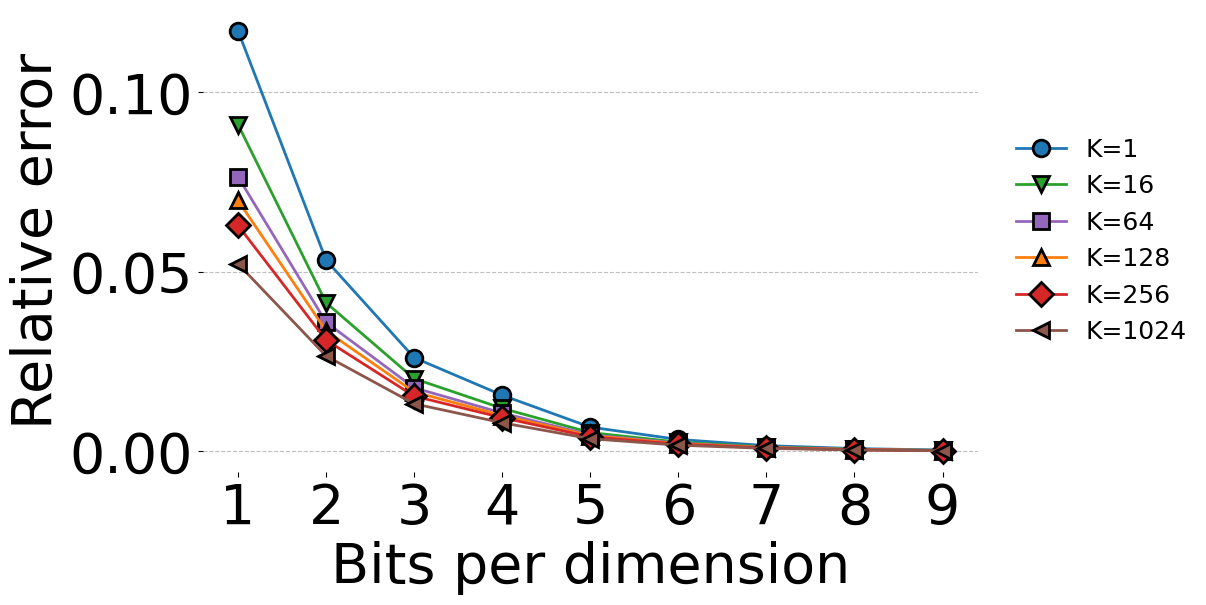

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_relerr_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_relerr_vs_K_by_bits.pdf


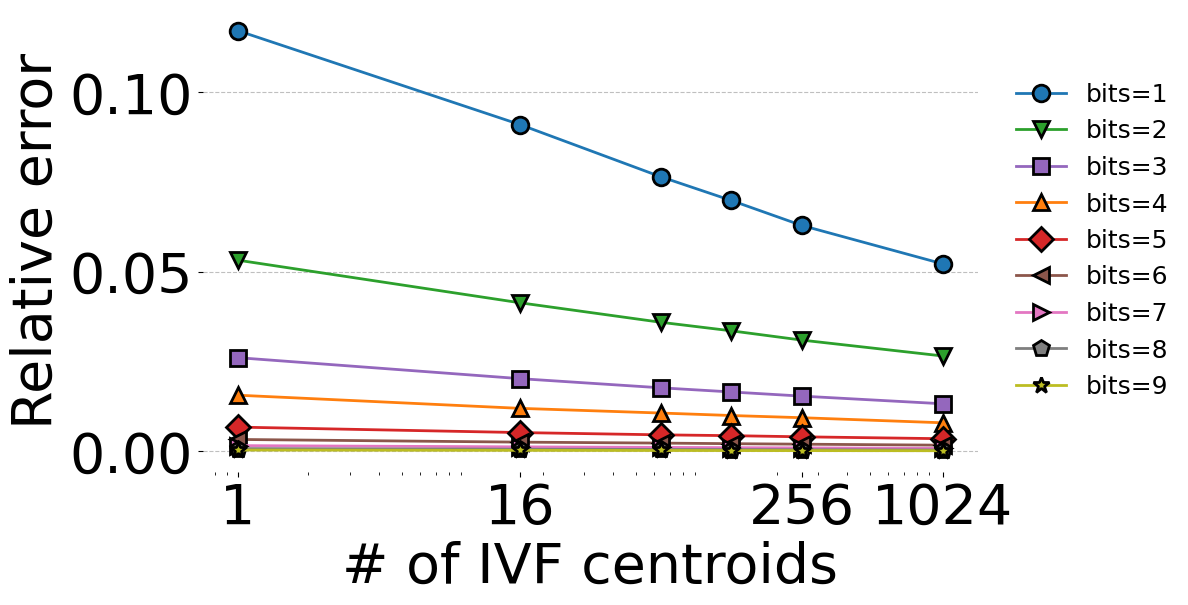

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_relerr_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_relerr_heatmap_bits_by_K.pdf


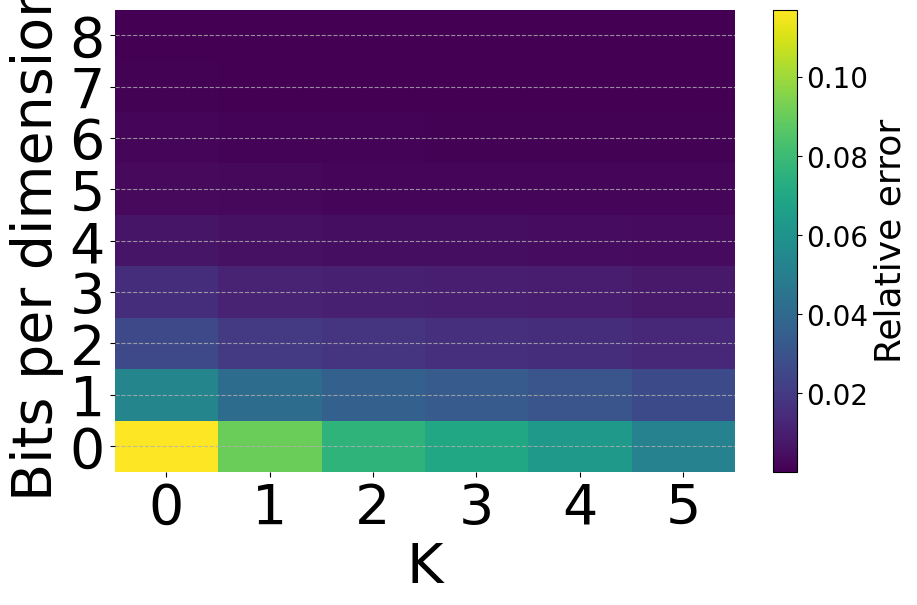

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_relerr_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_relerr_vs_bits_by_K.pdf


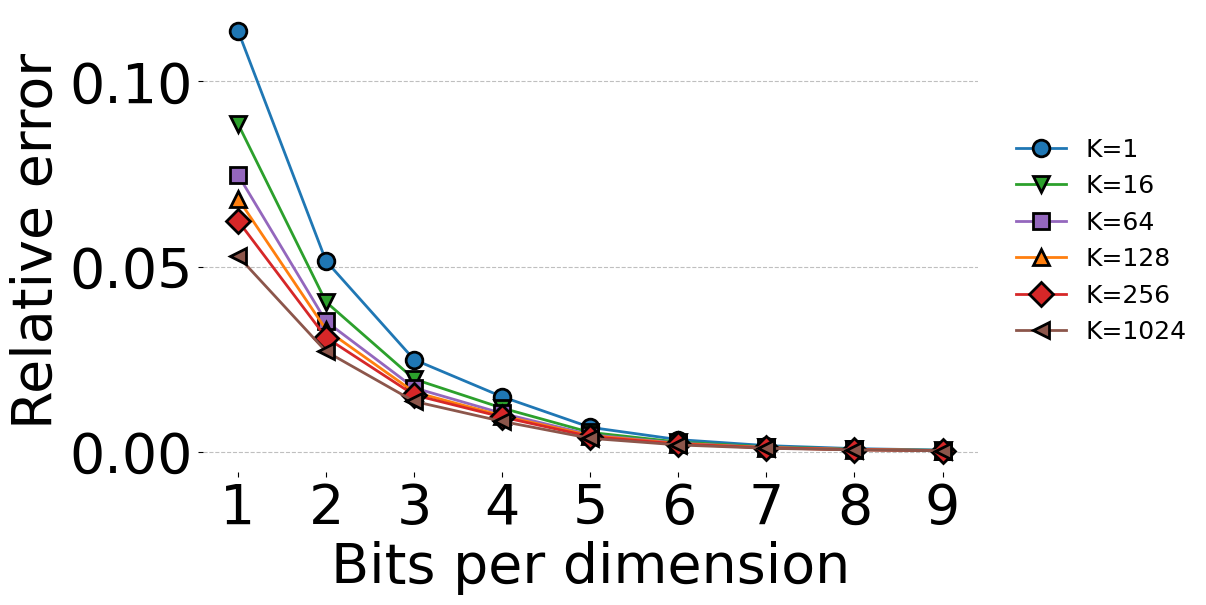

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_relerr_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_relerr_vs_K_by_bits.pdf


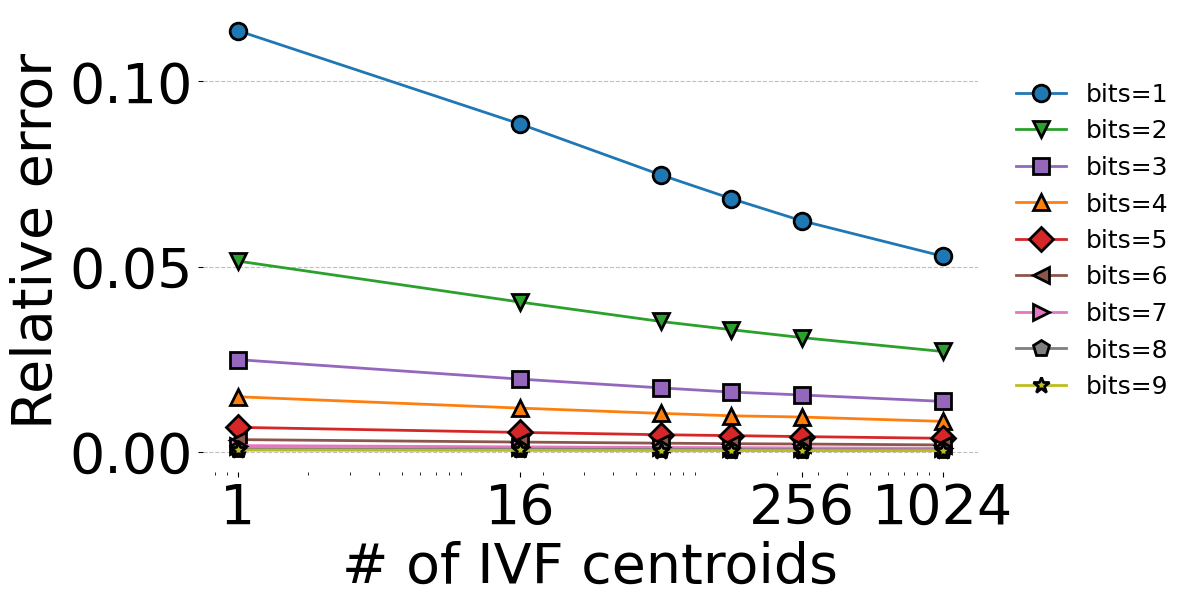

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_relerr_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_relerr_heatmap_bits_by_K.pdf


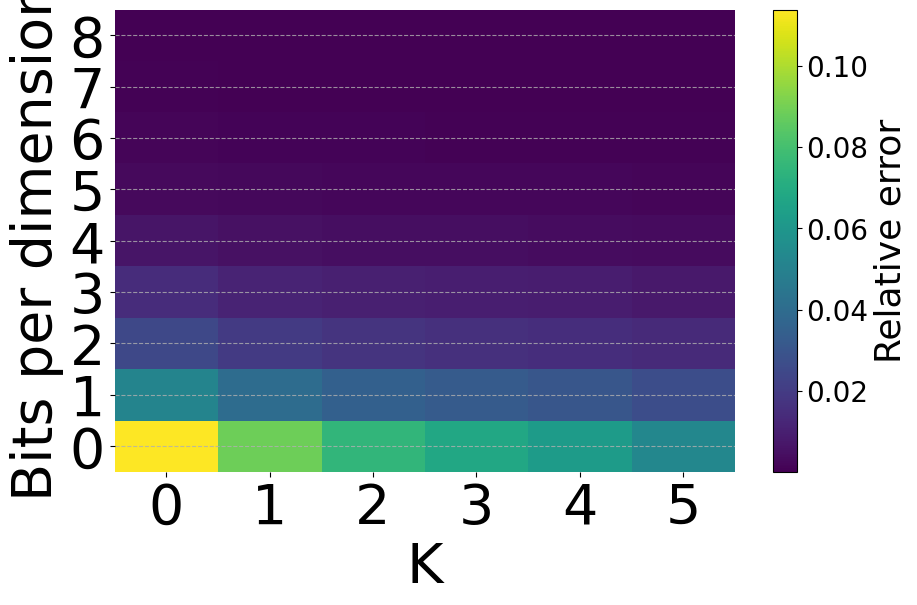

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_relerr_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_relerr_vs_bits_by_K.pdf


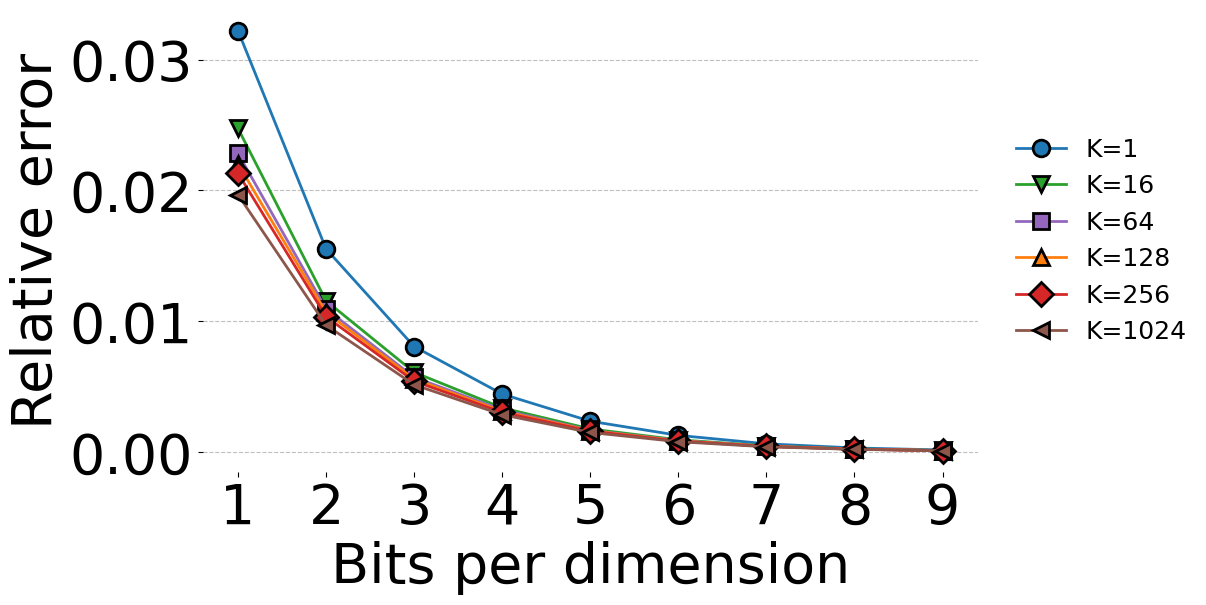

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_relerr_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_relerr_vs_K_by_bits.pdf


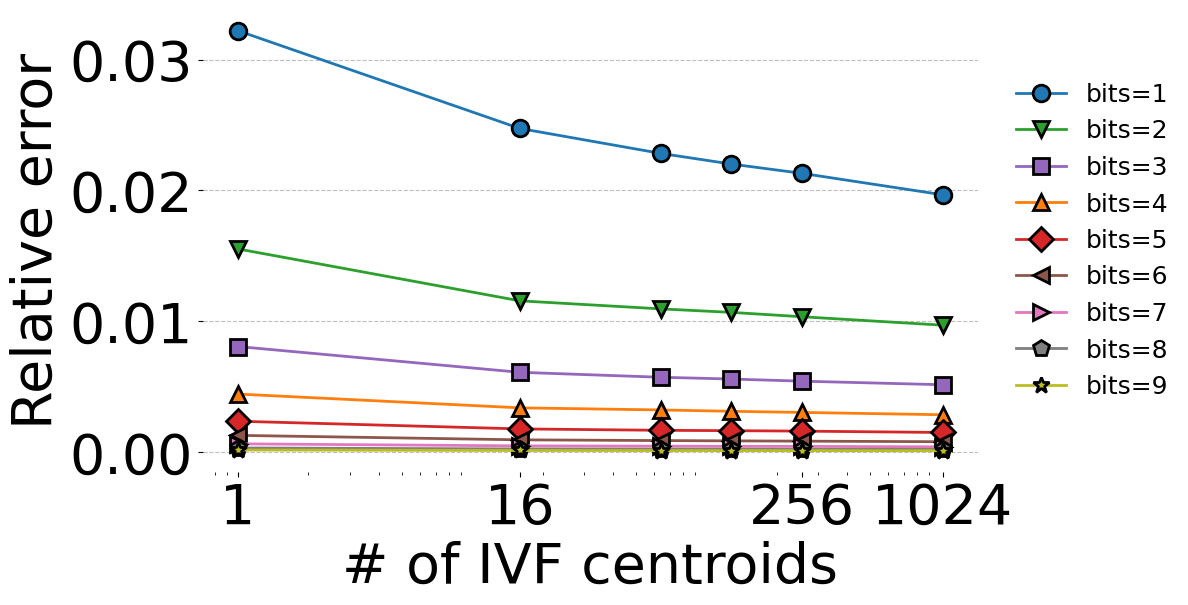

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_relerr_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_relerr_heatmap_bits_by_K.pdf


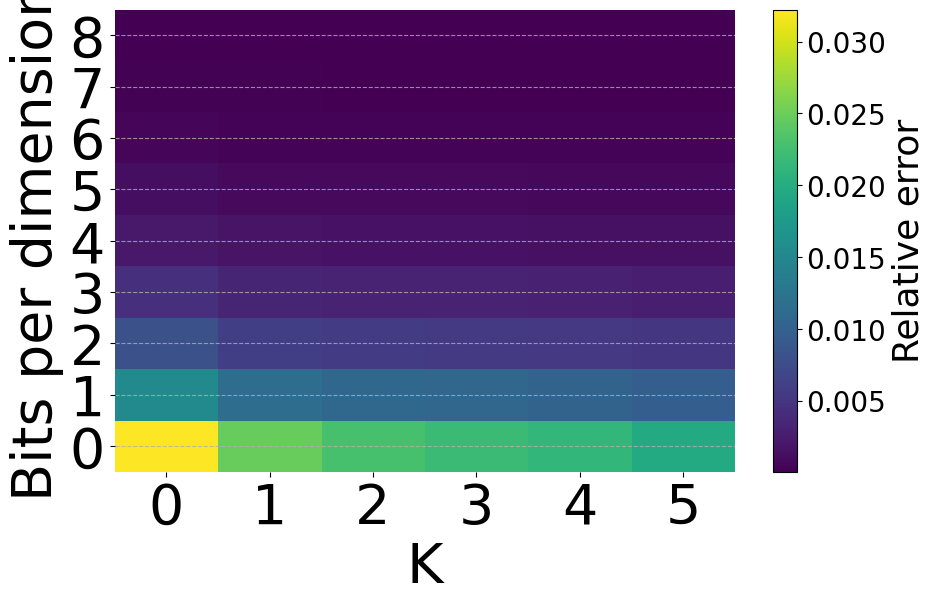

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_relerr_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_relerr_vs_bits_by_K.pdf


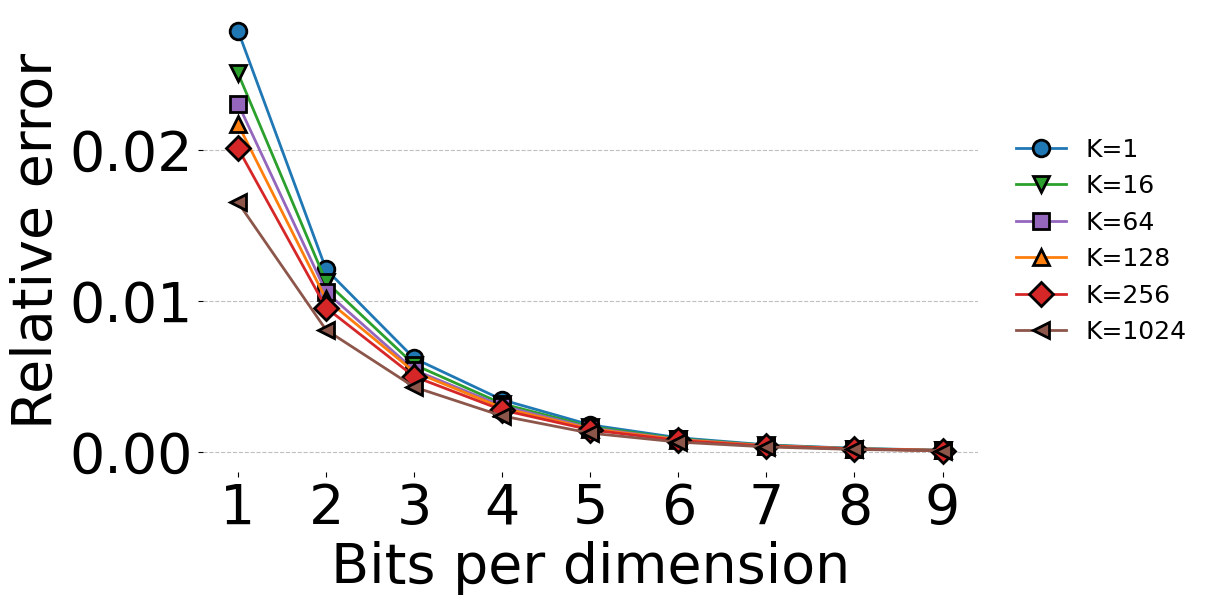

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_relerr_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_relerr_vs_K_by_bits.pdf


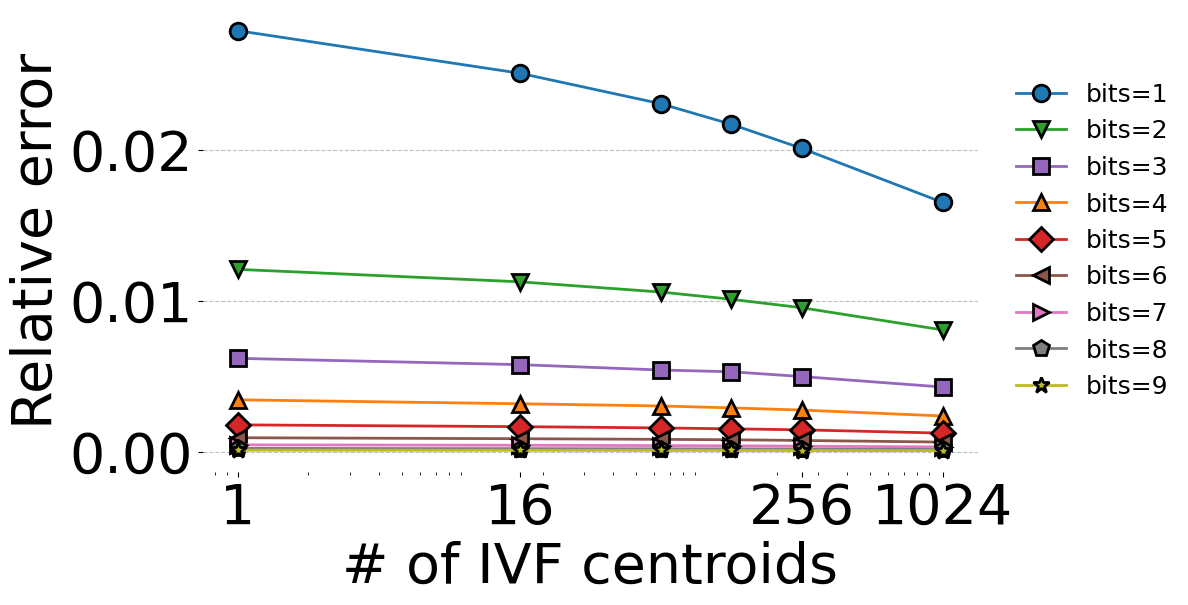

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_relerr_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_relerr_heatmap_bits_by_K.pdf


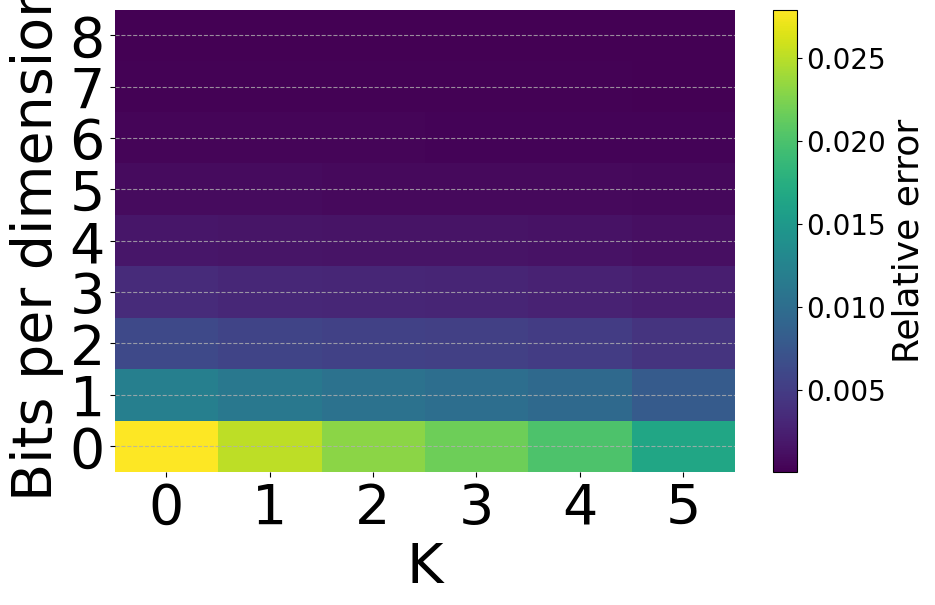

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_relerr_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_relerr_vs_bits_by_K.pdf


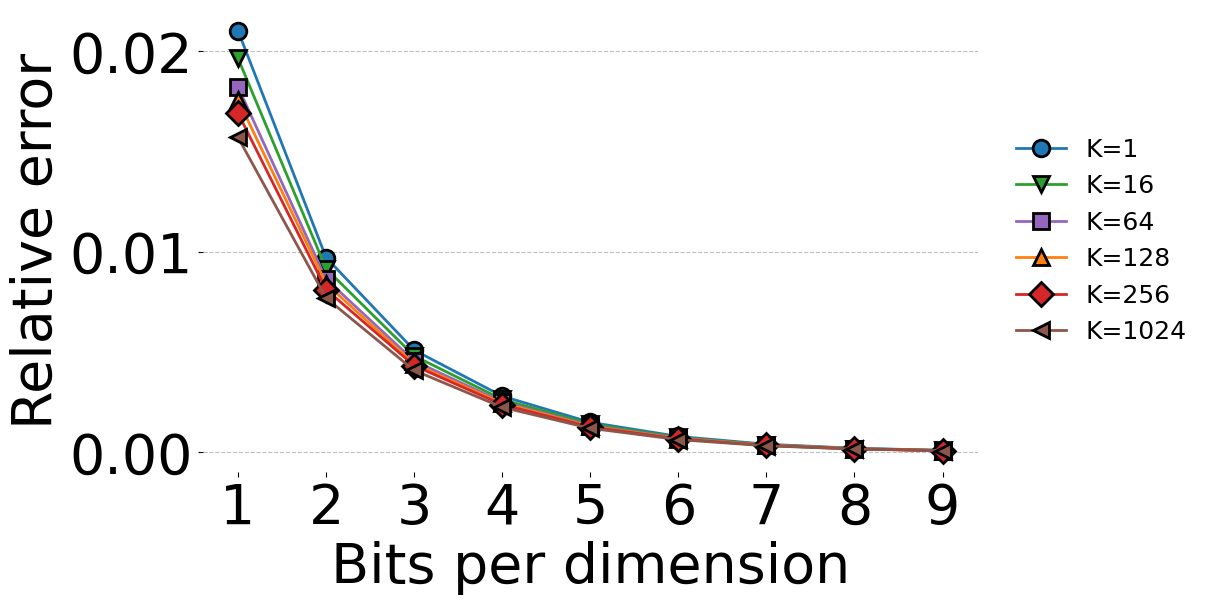

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_relerr_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_relerr_vs_K_by_bits.pdf


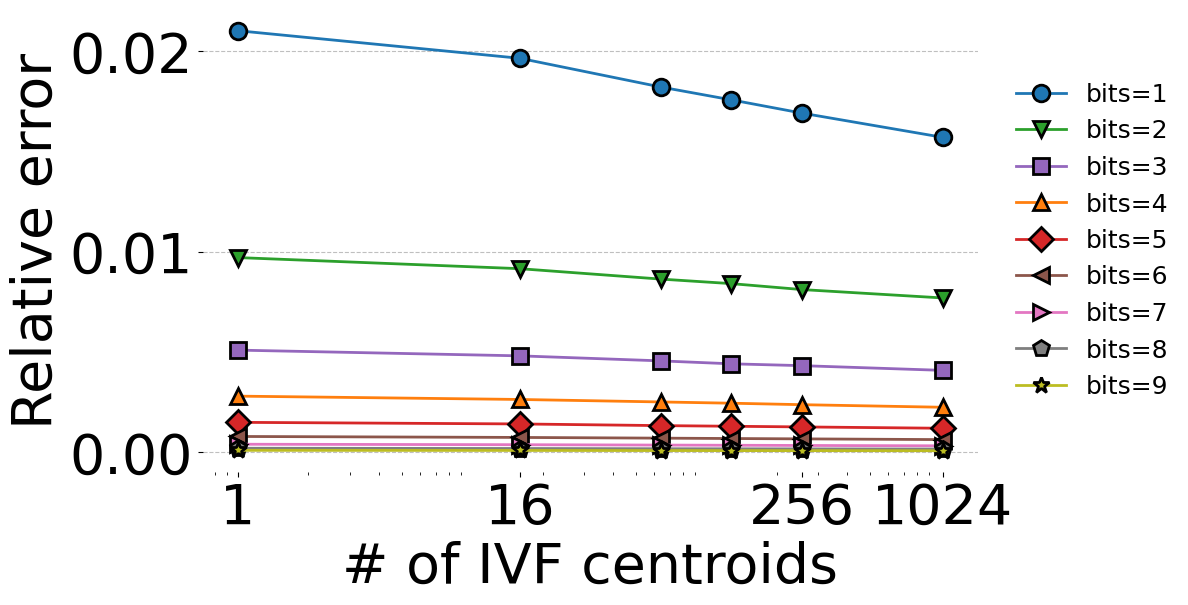

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_relerr_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_relerr_heatmap_bits_by_K.pdf


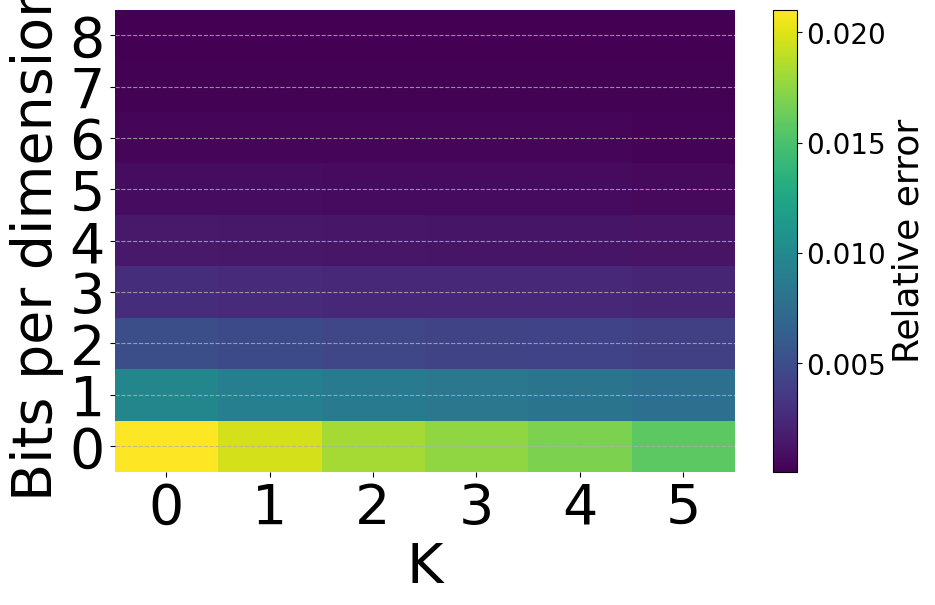

In [ ]:
for dataset in DATASETS:
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='bits',
        y_col='rel_error_mean',
        group_col='K',
        x_label='Bits per dimension',
        y_label='Relative error',
        stem='relerr_vs_bits_by_K',
        title=f'{dataset}: Relative error vs bits',
    )
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='K',
        y_col='rel_error_mean',
        group_col='bits',
        x_label='# of IVF centroids (K)',
        y_label='Relative error',
        stem='relerr_vs_K_by_bits',
        title=f'{dataset}: Relative error vs K',
        x_log=True,
    )
    plot_heatmap(
        plot_df,
        dataset=dataset,
        value_col='rel_error_mean',
        value_label='Relative error',
        stem='relerr_heatmap_bits_by_K',
    )


## ADC Timing Plots

`adc_time_per_pair_s` is the native RaBitQ timing normalized by the actual evaluated pair count.

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_adc_time_ns_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_adc_time_ns_vs_bits_by_K.pdf


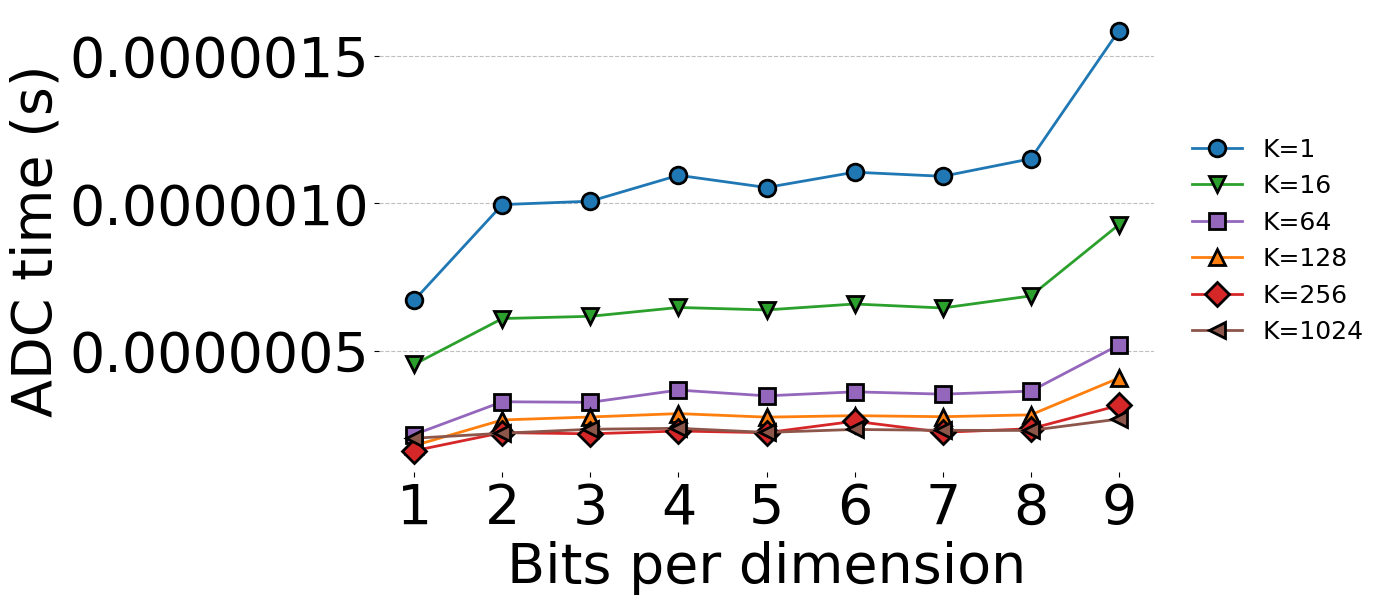

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_adc_time_ns_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_adc_time_ns_vs_K_by_bits.pdf


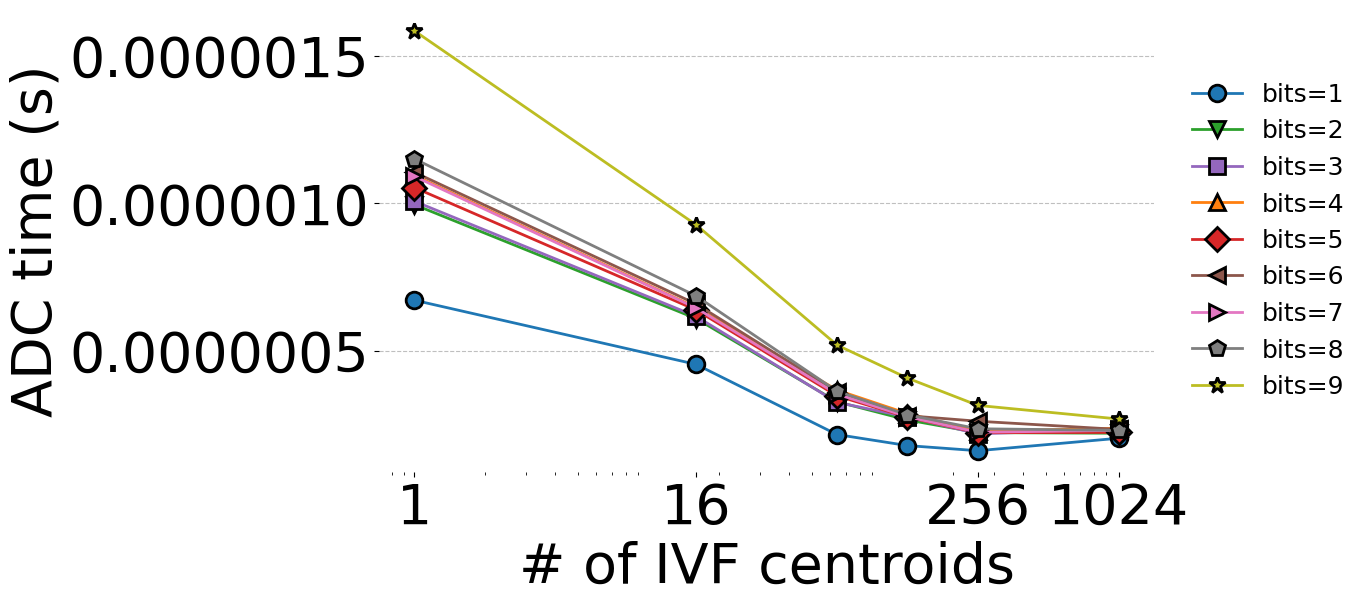

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_adc_time_ns_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_adc_time_ns_heatmap_bits_by_K.pdf


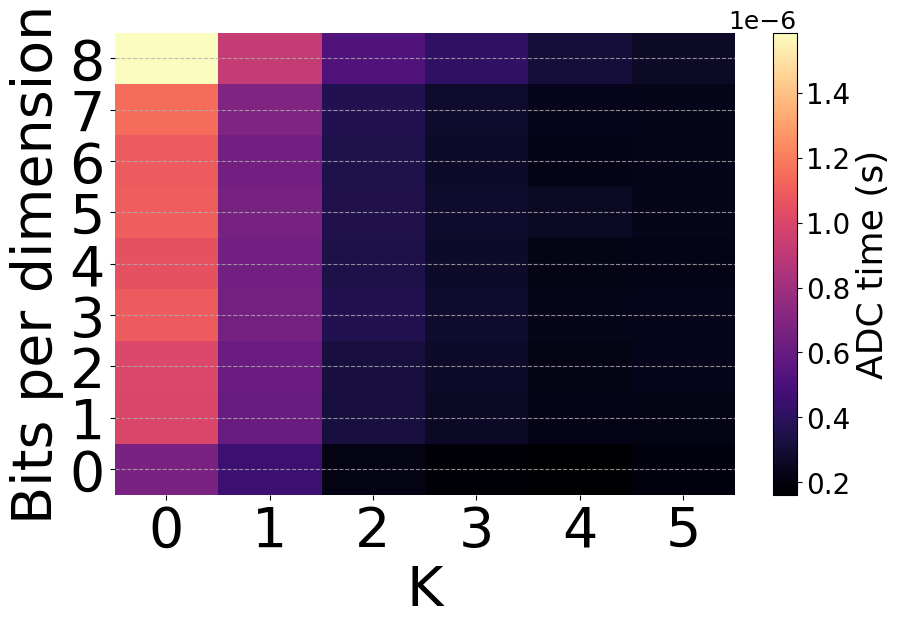

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_adc_time_ns_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_adc_time_ns_vs_bits_by_K.pdf


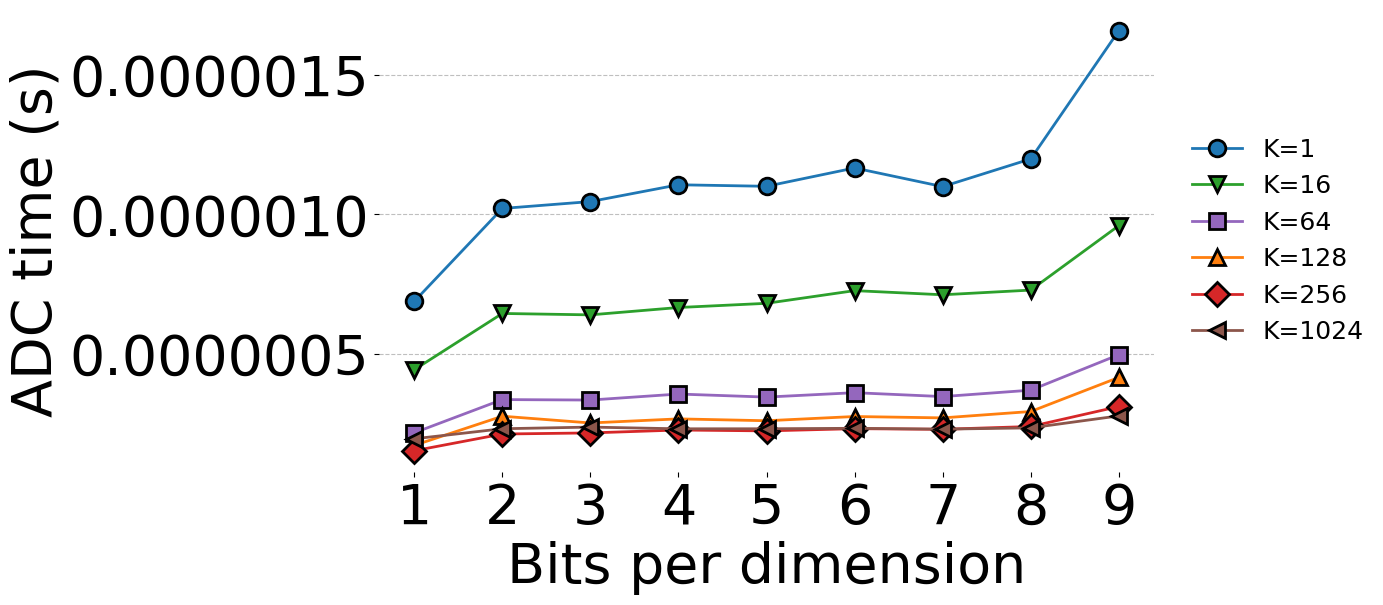

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_adc_time_ns_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_adc_time_ns_vs_K_by_bits.pdf


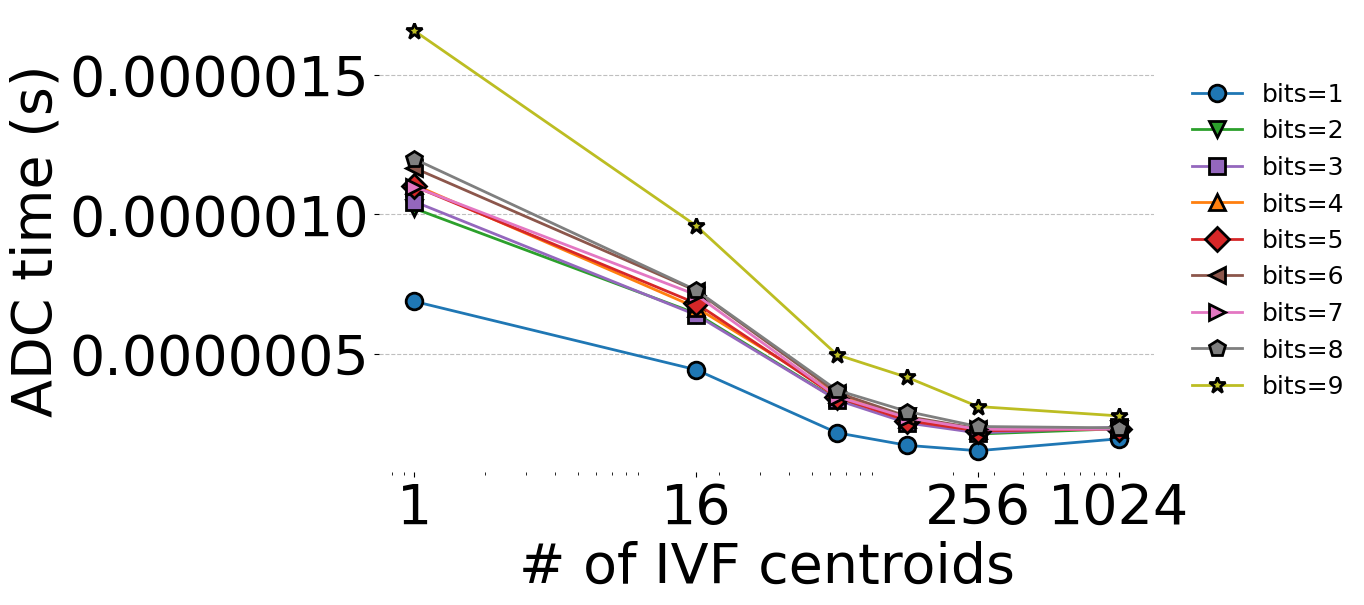

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_adc_time_ns_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_adc_time_ns_heatmap_bits_by_K.pdf


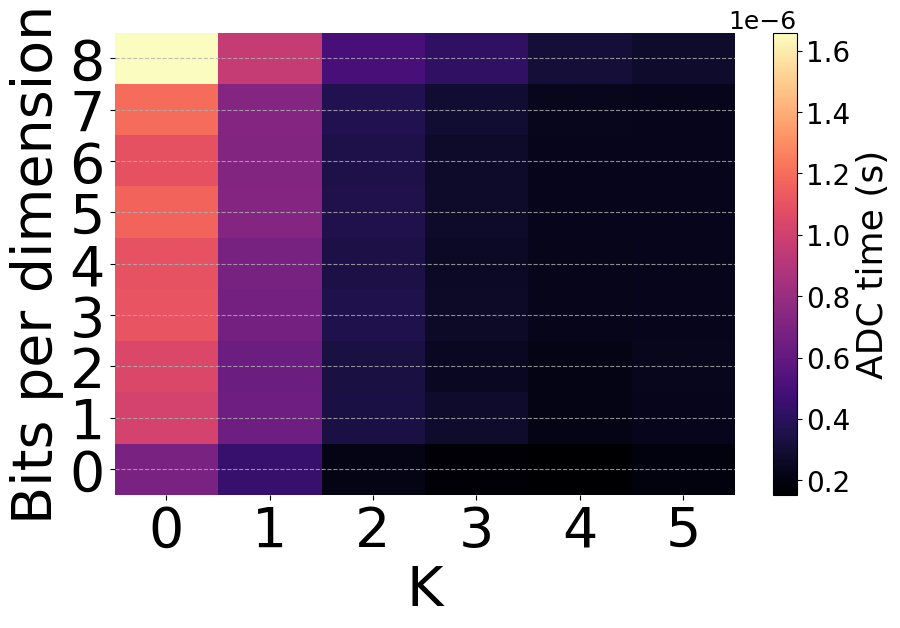

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_adc_time_ns_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_adc_time_ns_vs_bits_by_K.pdf


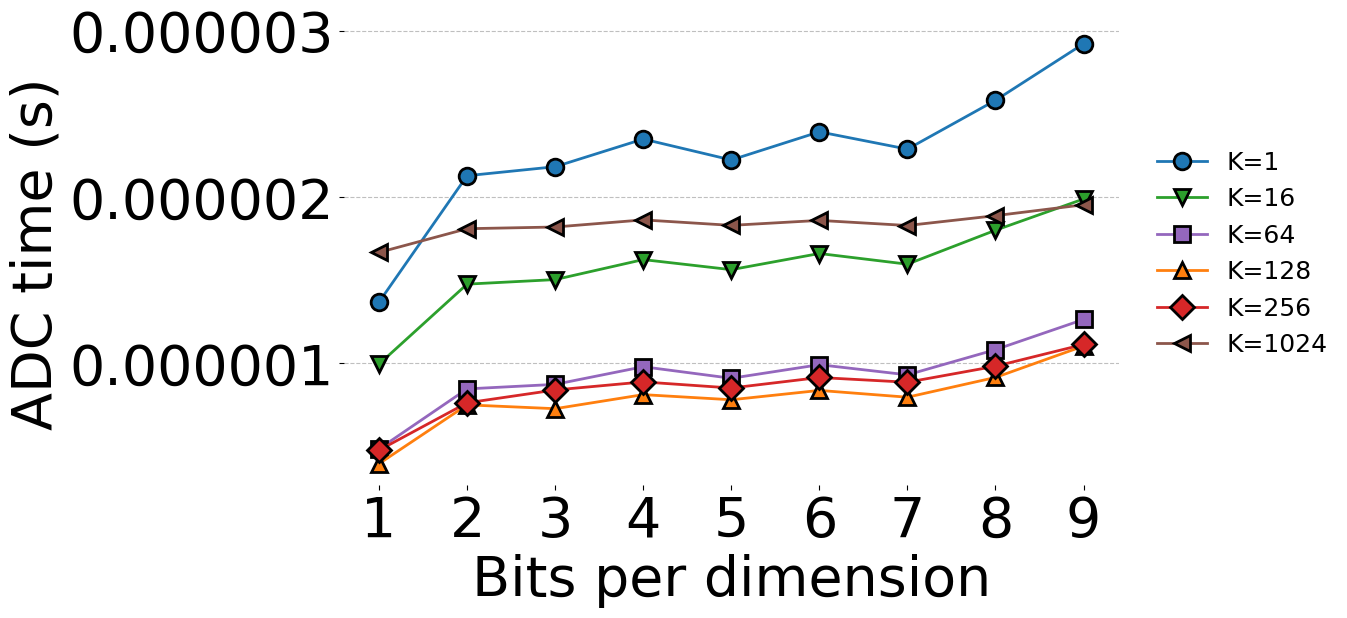

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_adc_time_ns_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_adc_time_ns_vs_K_by_bits.pdf


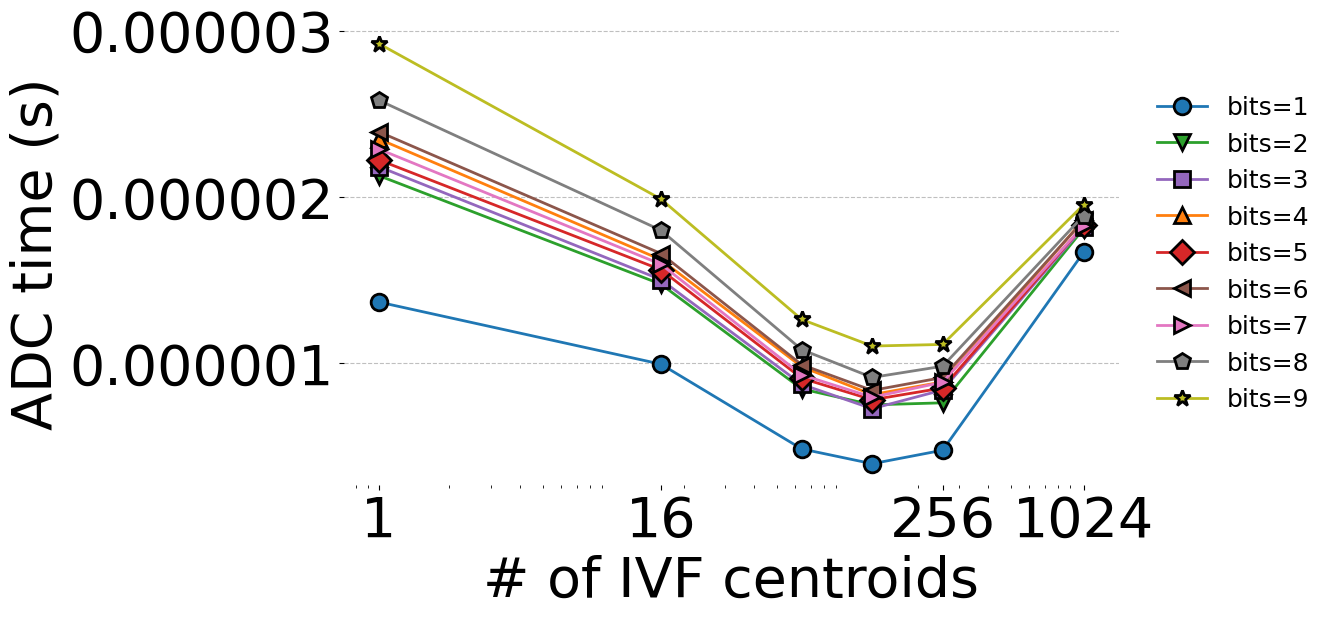

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_adc_time_ns_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_adc_time_ns_heatmap_bits_by_K.pdf


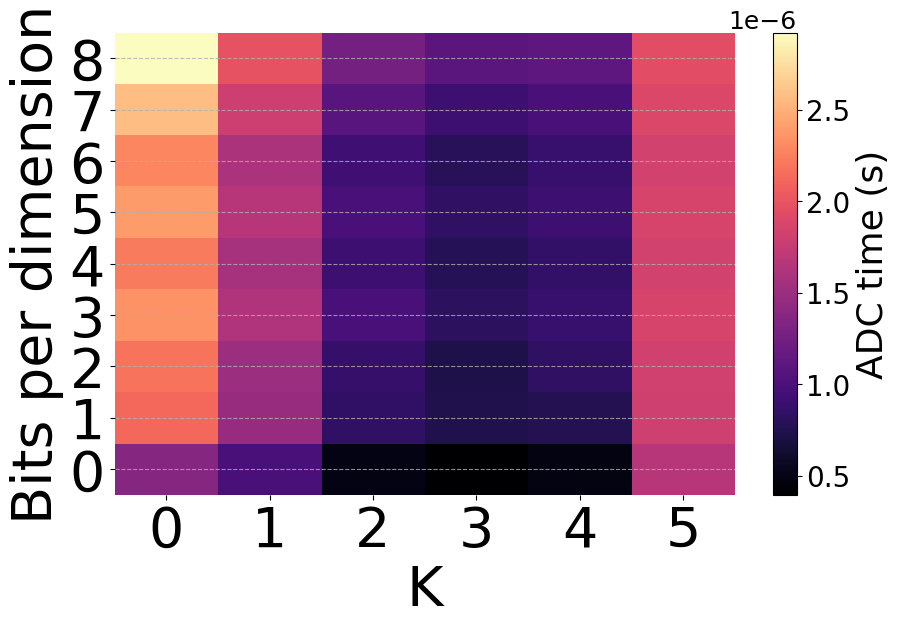

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_adc_time_ns_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_adc_time_ns_vs_bits_by_K.pdf


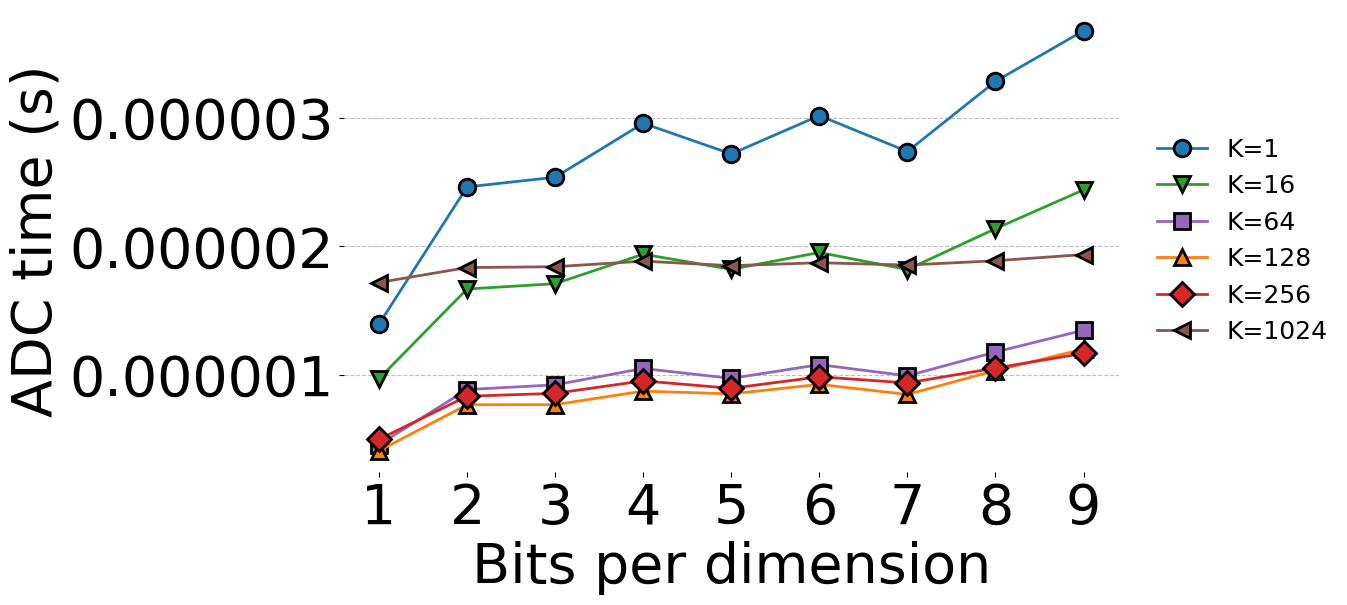

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_adc_time_ns_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_adc_time_ns_vs_K_by_bits.pdf


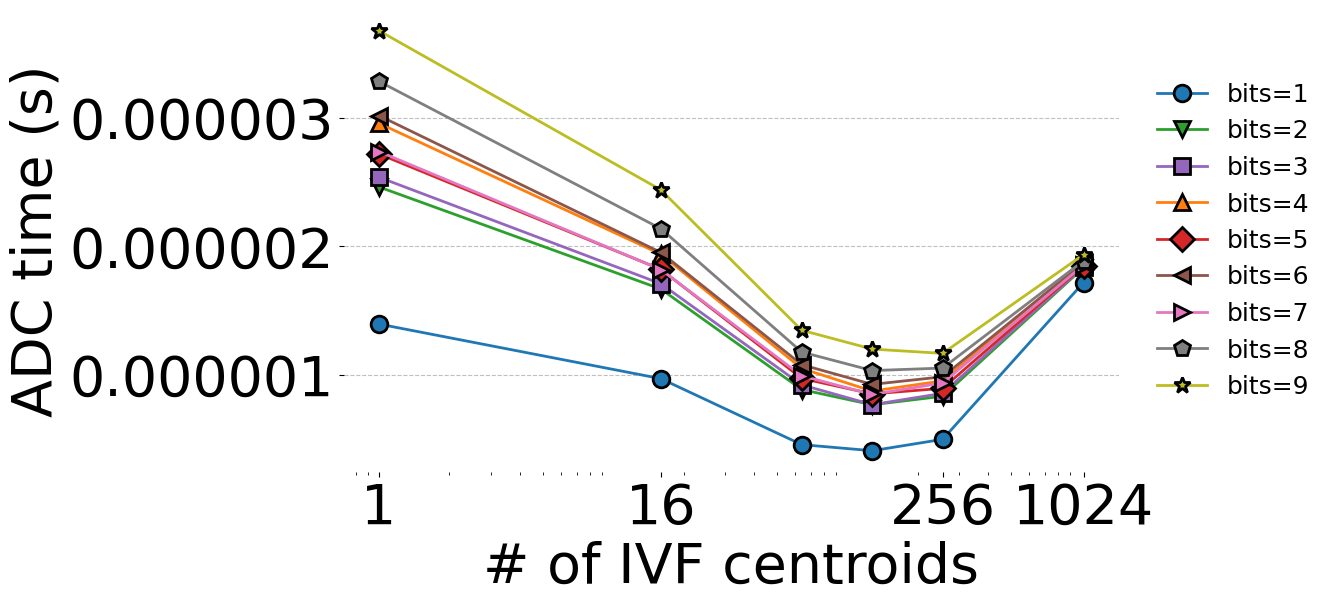

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_adc_time_ns_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_adc_time_ns_heatmap_bits_by_K.pdf


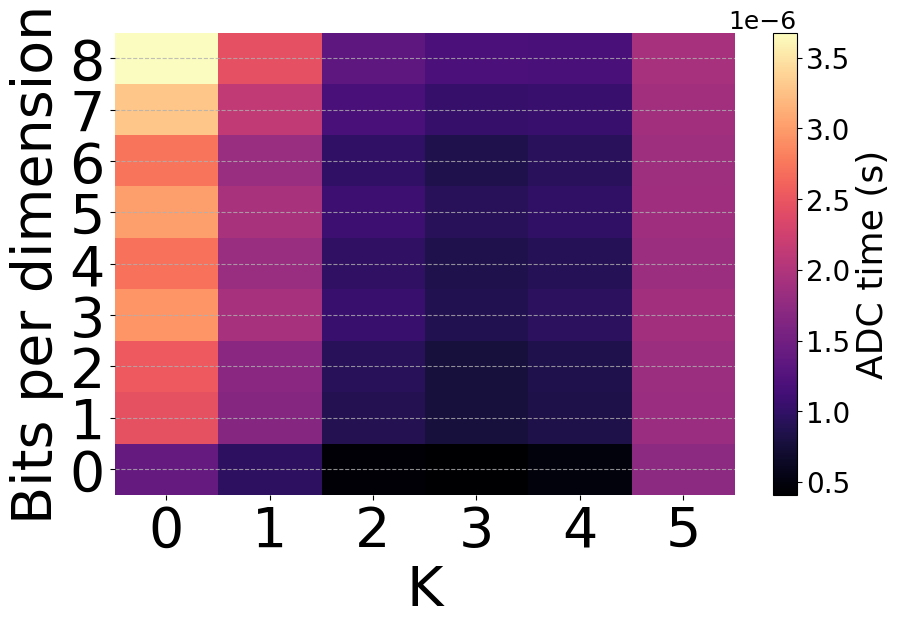

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_adc_time_ns_vs_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_adc_time_ns_vs_bits_by_K.pdf


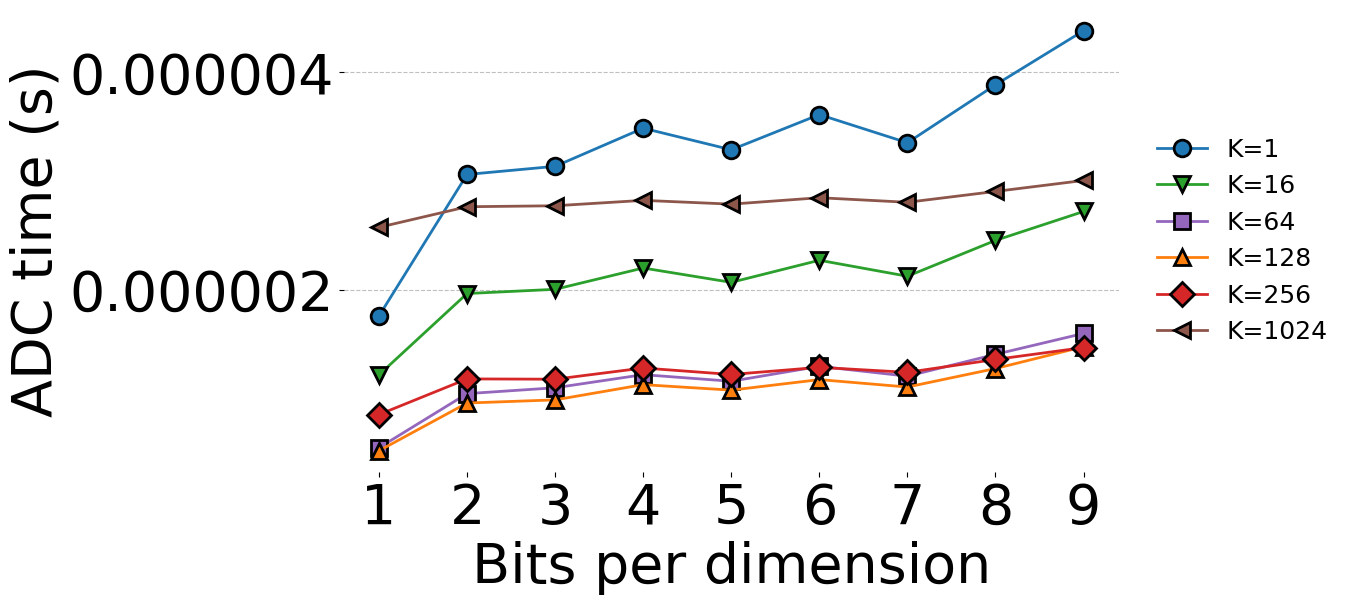

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_adc_time_ns_vs_K_by_bits.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_adc_time_ns_vs_K_by_bits.pdf


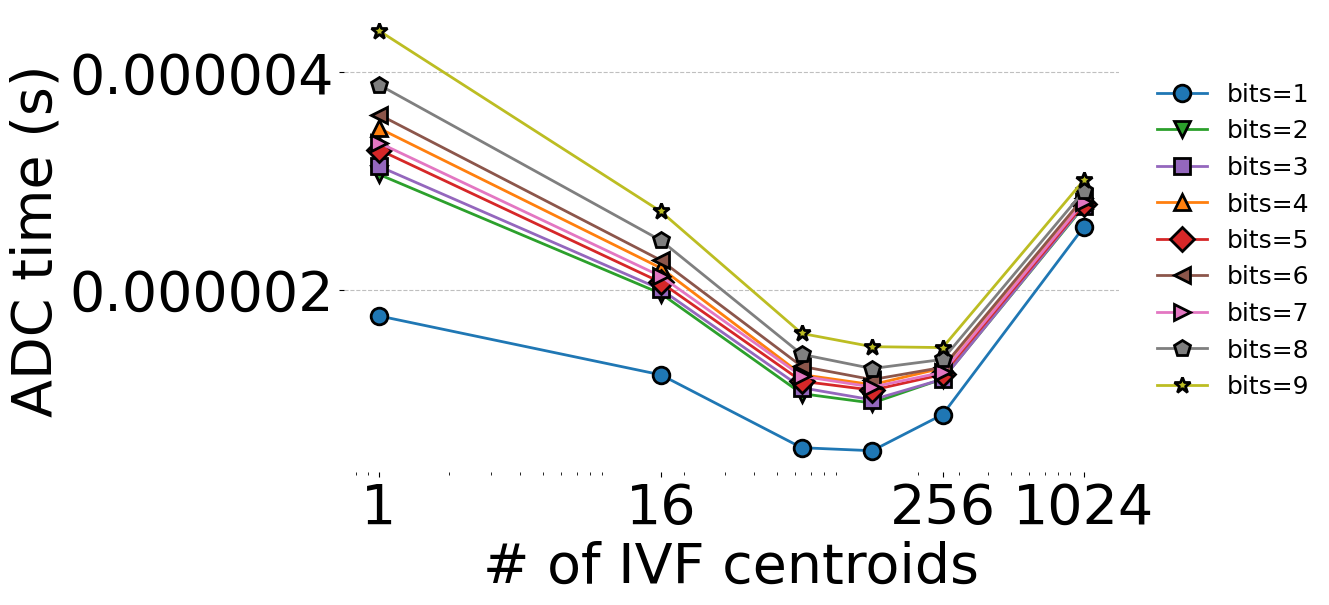

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_adc_time_ns_heatmap_bits_by_K.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_adc_time_ns_heatmap_bits_by_K.pdf


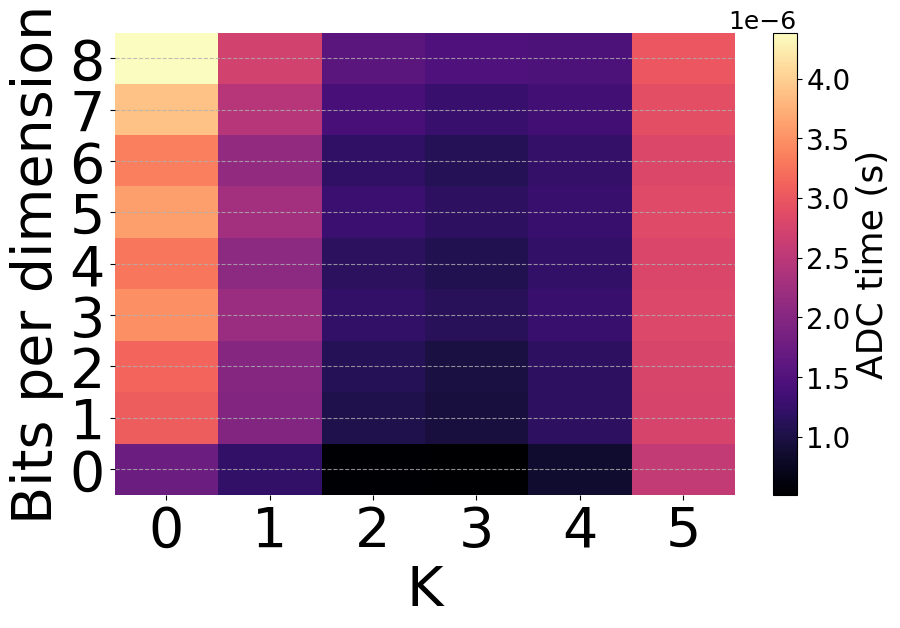

In [ ]:
for dataset in DATASETS:
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='bits',
        y_col='adc_time_per_pair_s',
        group_col='K',
        x_label='Bits per dimension',
        y_label='ADC time (s)',
        stem='adc_time_ns_vs_bits_by_K',
        title=f'{dataset}: ADC time vs bits',
    )
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='K',
        y_col='adc_time_per_pair_s',
        group_col='bits',
        x_label='# of IVF centroids (K)',
        y_label='ADC time (s)',
        stem='adc_time_ns_vs_K_by_bits',
        title=f'{dataset}: ADC time vs K',
        x_log=True,
    )
    plot_heatmap(
        plot_df,
        dataset=dataset,
        value_col='adc_time_per_pair_s',
        value_label='ADC time (s)',
        stem='adc_time_ns_heatmap_bits_by_K',
        cmap='magma',
    )


## Pareto: Relative Error vs ADC Time

Each point is one `(bits, K)` configuration. Only lower-left Pareto frontier points are highlighted in red and annotated.

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/bigann_pareto_relerr_vs_adc_time.pdf


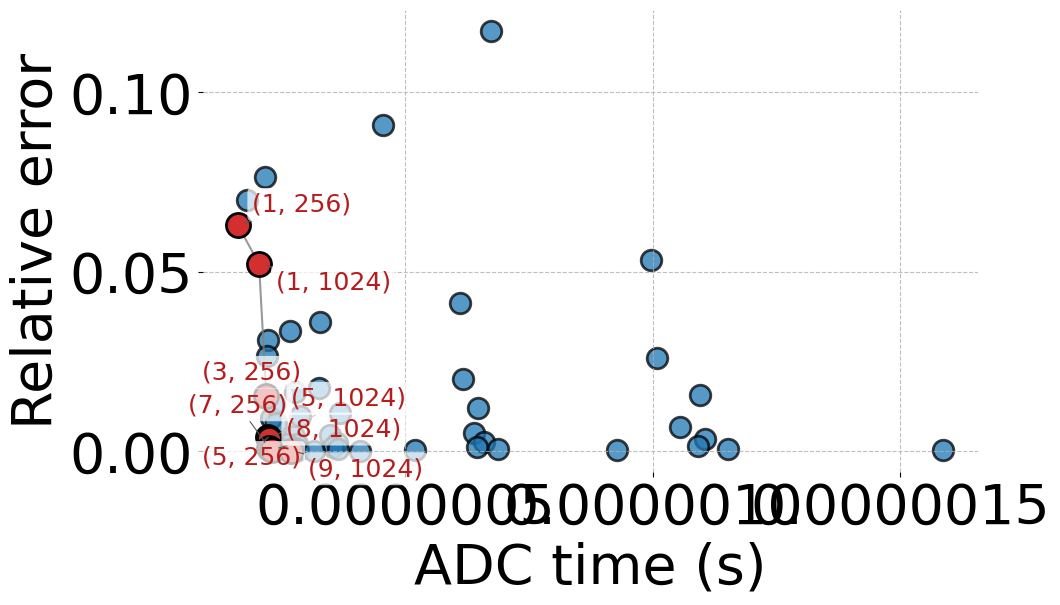

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/deep_pareto_relerr_vs_adc_time.pdf


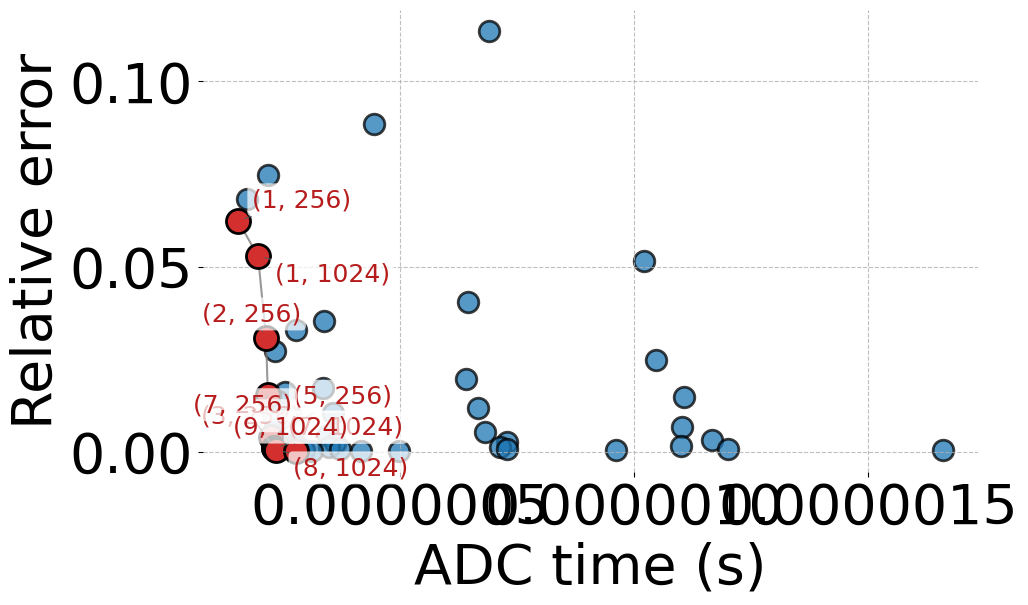

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/gist_pareto_relerr_vs_adc_time.pdf


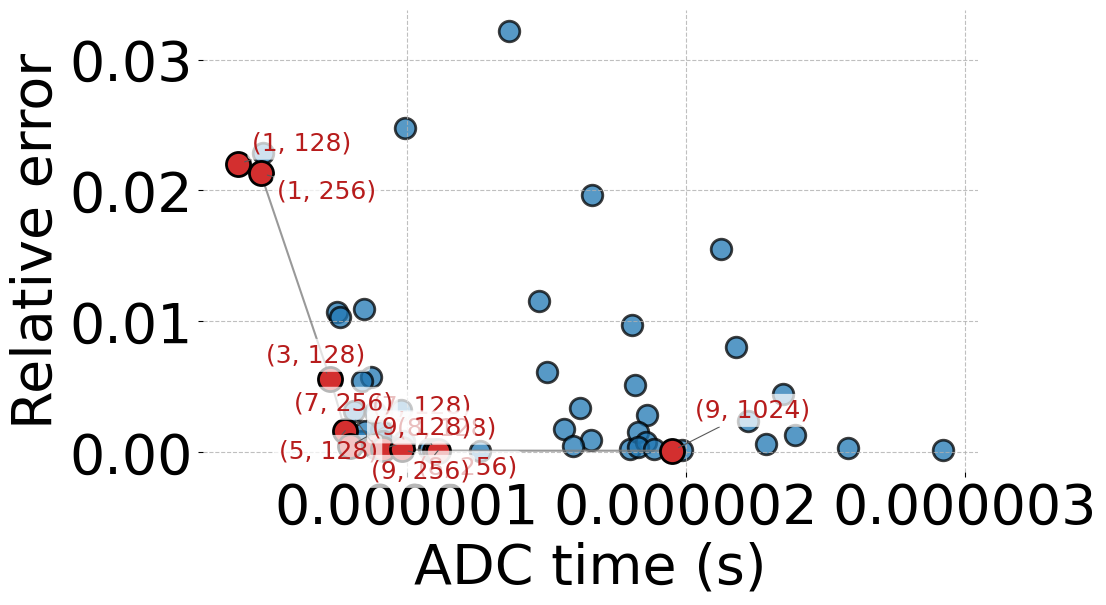

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/msmarco_pareto_relerr_vs_adc_time.pdf


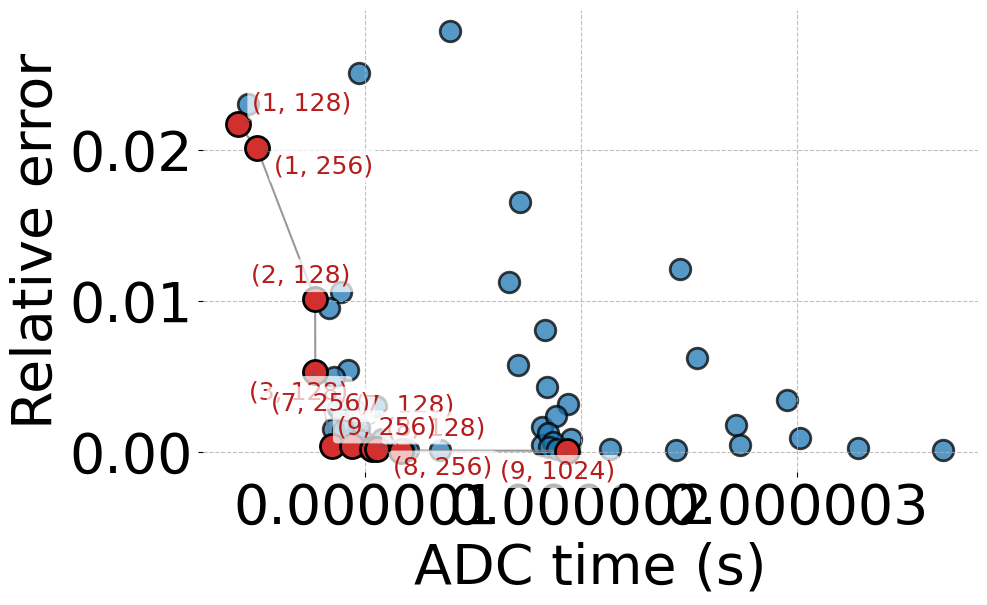

Saved: /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/rabitq/figures/rabitq_native_ivf_qinco_style/openai_pareto_relerr_vs_adc_time.pdf


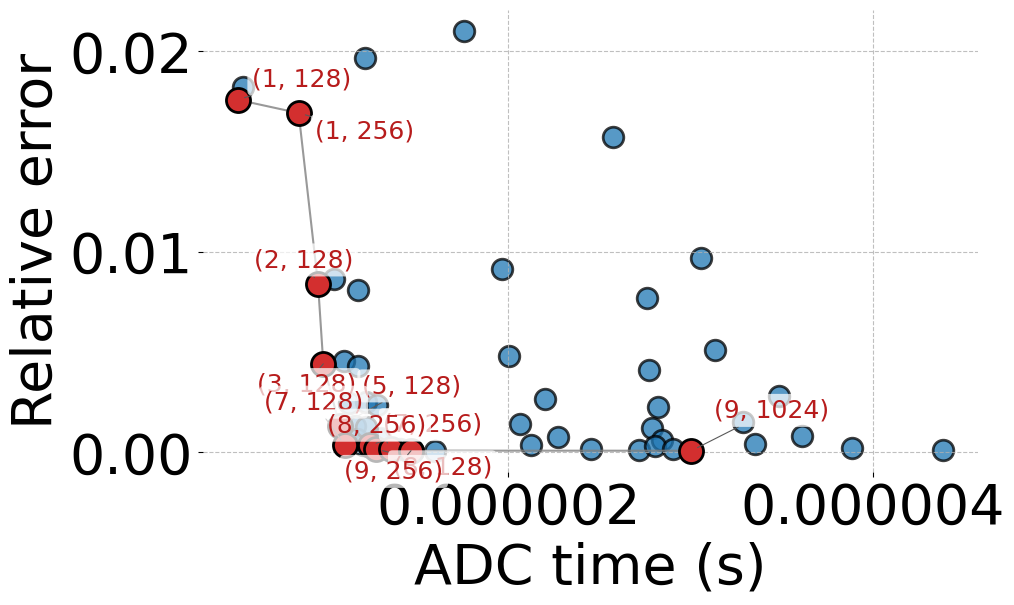

In [6]:
def pareto_frontier_minimize(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    pts = df.dropna(subset=[x_col, y_col]).sort_values([x_col, y_col]).copy()
    frontier = []
    best_y = np.inf
    for _, row in pts.iterrows():
        if row[y_col] < best_y:
            frontier.append(row)
            best_y = row[y_col]
    return pd.DataFrame(frontier) if frontier else pts.iloc[0:0]


def plot_pareto(dataset: str):
    sub = plot_df[plot_df['dataset'] == dataset].dropna(subset=['adc_time_per_pair_s', 'rel_error_mean']).copy()
    if sub.empty:
        return None
    frontier = pareto_frontier_minimize(sub, 'adc_time_per_pair_s', 'rel_error_mean')
    apply_relerr_cpp_rcparams()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(
        sub['adc_time_per_pair_s'],
        sub['rel_error_mean'],
        color='tab:blue',
        marker='o',
        s=220,
        edgecolors='black',
        linewidths=2,
        alpha=0.75,
    )
    if not frontier.empty:
        ax.plot(frontier['adc_time_per_pair_s'], frontier['rel_error_mean'], '-', color='gray', linewidth=1.5, alpha=0.8)
        ax.scatter(
            frontier['adc_time_per_pair_s'],
            frontier['rel_error_mean'],
            color='#D32F2F',
            marker='o',
            s=300,
            edgecolors='black',
            linewidths=2,
            zorder=3,
        )
        offsets = [(10, 10), (12, -18), (-46, 12), (-48, -20), (16, 24), (-58, 26)]
        for i, (_, row) in enumerate(frontier.iterrows()):
            ax.annotate(
                f"({int(row['bits'])}, {int(row['K'])})",
                (row['adc_time_per_pair_s'], row['rel_error_mean']),
                xytext=offsets[i % len(offsets)],
                textcoords='offset points',
                fontsize=18,
                color='#B71C1C',
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.72),
                arrowprops=dict(arrowstyle='-', color='0.35', lw=0.8, shrinkA=0, shrinkB=5),
            )
    style_axes(ax, 'ADC time (s)', 'Relative error', grid_axis='both')
    save_figure(fig, f'{dataset}_pareto_relerr_vs_adc_time')
    plt.show()
    plt.close(fig)
    return fig


for dataset in DATASETS:
    plot_pareto(dataset)


## Combined Data Table

`plot_df` is the aggregated table used for the figures.

In [7]:
display_cols = [
    'dataset', 'bits', 'K', 'nbits', 'bits_per_vector',
    'adc_time_per_pair_ns', 'adc_time_s',
    'rel_error_mean', 'rel_error_std',
    'timing_rows',
]
plot_df[display_cols].sort_values(['dataset', 'bits', 'K']).head(30)


,dataset,bits,K,nbits,bits_per_vector,adc_time_per_pair_ns,adc_time_s,rel_error_mean,rel_error_std,timing_rows
0,bigann,1,1,1,128,671.927,0.067193,0.117065,0.081608,1
9,bigann,1,16,1,128,454.470,0.045447,0.090968,0.065443,1
18,bigann,1,64,1,128,216.675,0.021667,0.076436,0.057148,1
27,bigann,1,128,1,128,179.217,0.017922,0.069844,0.053140,1
36,bigann,1,256,1,128,161.780,0.016178,0.062902,0.048641,1
45,bigann,1,1024,1,128,204.158,0.020416,0.052219,0.041518,1
1,bigann,2,1,2,256,995.844,0.099584,0.053219,0.042048,1
10,bigann,2,16,2,256,609.736,0.060974,0.041380,0.031898,1
19,bigann,2,64,2,256,327.715,0.032772,0.035949,0.027809,1
28,bigann,2,128,2,256,266.066,0.026607,0.033575,0.026261,1
